# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 09: Árvores de Decisão e k-Means**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_09_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
url = "https://gist.githubusercontent.com/marcelovca90/de69333ef1e36f6ce4671e387f820f34/raw/29d61f2789c51a84144192a8127c5b041fa8bca2/wifi_localization.txt"

column_names = [ "AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7", "Room" ]

df = pd.read_csv(url, sep="\t", header=None, names=column_names)

X = df.drop(columns=["Room"]).values
y = df["Room"].values

feature_names = df.columns[:-1].tolist()

df.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### <font color='#2D9CDB'>Q1) O Wireless Indoor Localization [[1]](https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization)[[2]](https://archive-beta.ics.uci.edu/dataset/422/wireless+indoor+localization) é um conjunto de dados amplamente utilizado em pesquisas sobre posicionamento indoor e redes sem fio. Pesquise brevemente sobre esse dataset e descreva, em um único parágrafo, qual é o problema que ele busca resolver, quais informações são registradas em cada amostra, o significado dos valores RSSI (Received Signal Strength Indicator) e por que essa base de dados pode ser utilizada tanto em problemas de classificação quanto de clusterização.</font>

O dataset Wireless Indoor Localization foi desenvolvido para o problema de localização de dispositivos em ambientes internos utilizando sinais Wi-Fi. Cada amostra representa uma medição dos níveis de intensidade de sinal recebidos de sete pontos de acesso Wi-Fi, juntamente com a identificação da sala onde a medição foi realizada.

Os valores RSSI indicam a potência do sinal recebido.

Esse dataset pode ser utilizado em problemas de classificação porque as salas são conhecidas e podem ser previstas a partir dos sinais recebidos. Também pode ser utilizado em problemas de clusterização, pois os padrões de RSSI permitem agrupar automaticamente medições semelhantes sem utilizar os rótulos das salas.


### <font color='#2D9CDB'>Q2) Utilizando o dataset Wireless Indoor Localization já carregado, informe a quantidade total de amostras, o número de atributos, o número de classes e os identificadores das salas presentes na base de dados. Em seguida, apresente uma tabela contendo as cinco primeiras amostras do conjunto de dados. Com base nos resultados obtidos, descreva brevemente a estrutura do dataset e o significado dos atributos e da variável alvo.</font>

In [4]:
print("Quantidade de amostras:", df.shape[0])
print("Número de atributos:", df.shape[1]-1)
print("Número de classes:", df["Room"].nunique())
print("Salas presentes:", sorted(df["Room"].unique()))

display(df.head())

Quantidade de amostras: 2000
Número de atributos: 7
Número de classes: 4
Salas presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


O dataset possui sete atributos de entrada (AP1 a AP7), correspondentes às intensidades de sinal RSSI dos pontos de acesso Wi-Fi. A variável alvo é Room, que identifica a sala onde a medição foi realizada. Cada linha representa uma observação independente do ambiente.

### <font color='#2D9CDB'>Q3) Utilizando apenas os atributos RSSI do dataset, apresente as estatísticas descritivas (contagem, média, desvio padrão, valor mínimo, quartis e valor máximo) de cada ponto de acesso Wi-Fi. Em seguida, identifique quais pontos de acesso apresentam, em média, os sinais mais fortes e os mais fracos. Com base nos resultados obtidos, comente brevemente sobre a variabilidade das medições de RSSI observadas no conjunto de dados.</font>

In [5]:
estatisticas = df.iloc[:, :-1].describe()

display(estatisticas)

medias = df.iloc[:, :-1].mean()

print("Sinais mais fortes:")
print(medias.sort_values(ascending=False))

print("\nAP mais forte:", medias.idxmax())
print("AP mais fraco:", medias.idxmin())

,AP1,AP2,AP3,AP4,AP5,AP6,AP7
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-52.330500,-55.623500,-54.964000,-53.566500,-62.640500,-80.985000,-81.726500
std,11.321677,3.417688,5.316186,11.471982,9.105093,6.516672,6.519812
min,-74.000000,-74.000000,-73.000000,-77.000000,-89.000000,-97.000000,-98.000000
25%,-61.000000,-58.000000,-58.000000,-63.000000,-69.000000,-86.000000,-87.000000
50%,-55.000000,-56.000000,-55.000000,-56.000000,-64.000000,-82.000000,-83.000000
75%,-46.000000,-53.000000,-51.000000,-46.000000,-56.000000,-77.000000,-78.000000
max,-10.000000,-45.000000,-40.000000,-11.000000,-36.000000,-61.000000,-63.000000


Sinais mais fortes:
AP1   -52.3305
AP4   -53.5665
AP3   -54.9640
AP2   -55.6235
AP5   -62.6405
AP6   -80.9850
AP7   -81.7265
dtype: float64

AP mais forte: AP1
AP mais fraco: AP7


Os APs com médias mais altas apresentam sinais mais fortes. O desvio padrão indica a variabilidade das medições. Valores elevados sugerem maior oscilação do sinal, enquanto valores menores indicam maior estabilidade.

### <font color='#2D9CDB'>Q4) Construa histogramas para os sete atributos RSSI do dataset e analise a distribuição dos valores observados. Em seguida, identifique quais pontos de acesso apresentam distribuições mais concentradas e quais apresentam maior dispersão. Com base nos gráficos obtidos, discuta brevemente como essas diferenças podem influenciar tarefas de classificação e clusterização.</font>

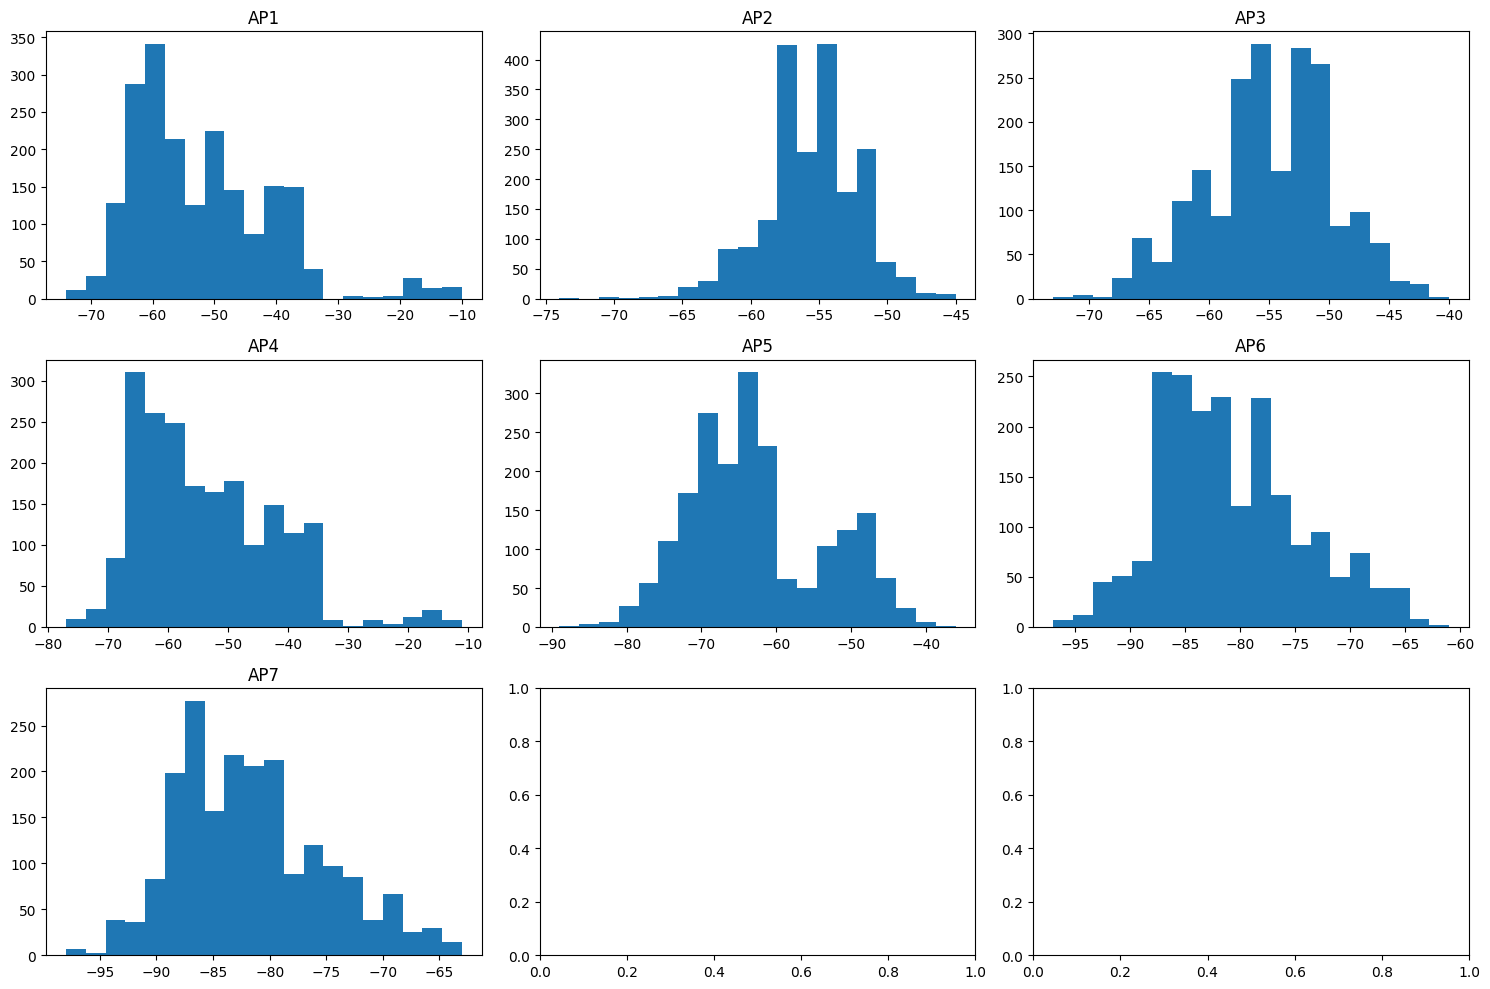

In [6]:
fig, axes = plt.subplots(3,3, figsize=(15,10))

axes = axes.flatten()

for i,col in enumerate(feature_names):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

APs com histogramas mais estreitos possuem menor dispersão, já as APs com distribuições mais espalhadas apresentam maior variabilidade.

Atributos com boa separação entre valores podem auxiliar tanto a classificação quanto a clusterização.

### <font color='#2D9CDB'>Q5) Analise a distribuição das amostras entre as diferentes salas do dataset. Para isso, apresente a quantidade de exemplos pertencentes a cada classe e construa um gráfico de barras mostrando essa distribuição. Em seguida, informe se o conjunto de dados é balanceado e discuta brevemente como o balanceamento das classes pode influenciar o treinamento e a avaliação de modelos de classificação.</font>

Room
1    500
2    500
3    500
4    500
Name: count, dtype: int64


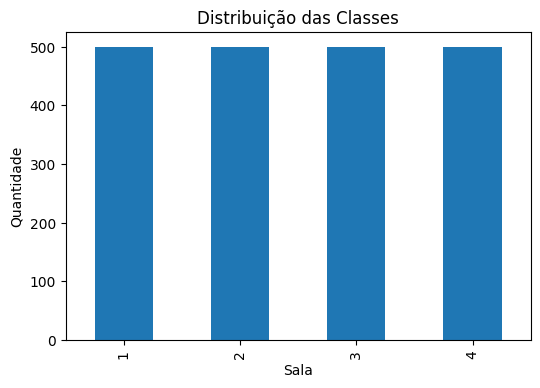

In [7]:
contagem = df["Room"].value_counts().sort_index()

print(contagem)

plt.figure(figsize=(6,4))
contagem.plot(kind='bar')
plt.xlabel("Sala")
plt.ylabel("Quantidade")
plt.title("Distribuição das Classes")
plt.show()

O conjunto é balanceado porque cada sala possui aproximadamente a mesma quantidade de amostras, isso reduz vieses durante o treinamento e torna a avaliação mais confiável.

### <font color='#2D9CDB'>Q6) Divida o dataset em conjuntos de treinamento e teste utilizando 70% das amostras para treinamento e 30% para teste. Utilize estratificação para preservar a proporção das classes em ambos os conjuntos. Em seguida, informe a quantidade de amostras presente em cada conjunto e verifique se a distribuição das classes foi mantida após a divisão.</font>

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape[0])
print("Teste:", X_test.shape[0])

print("\nDistribuição original")
print(pd.Series(y).value_counts(normalize=True))

print("\nDistribuição treino")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nDistribuição teste")
print(pd.Series(y_test).value_counts(normalize=True))

Treino: 1400
Teste: 600

Distribuição original
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64

Distribuição treino
2    0.25
3    0.25
1    0.25
4    0.25
Name: proportion, dtype: float64

Distribuição teste
4    0.25
2    0.25
3    0.25
1    0.25
Name: proportion, dtype: float64


A estratificação preservou a proporção das classes nos conjuntos de treinamento e teste.

# <font color='green'><u><b>Parte 2 - Árvore de Decisão</b></u></font>

### <font color='#2D9CDB'>Q7) Treine uma árvore de decisão para classificar as salas do dataset utilizando os dados de treinamento. Em seguida, informe a profundidade da árvore, o número de nós folha e apresente uma visualização da estrutura aprendida pelo modelo. Com base na árvore obtida, identifique qual atributo foi utilizado no nó raiz e discuta brevemente o que isso indica sobre sua importância para o processo de classificação.</font>

Profundidade: 13
Folhas: 37


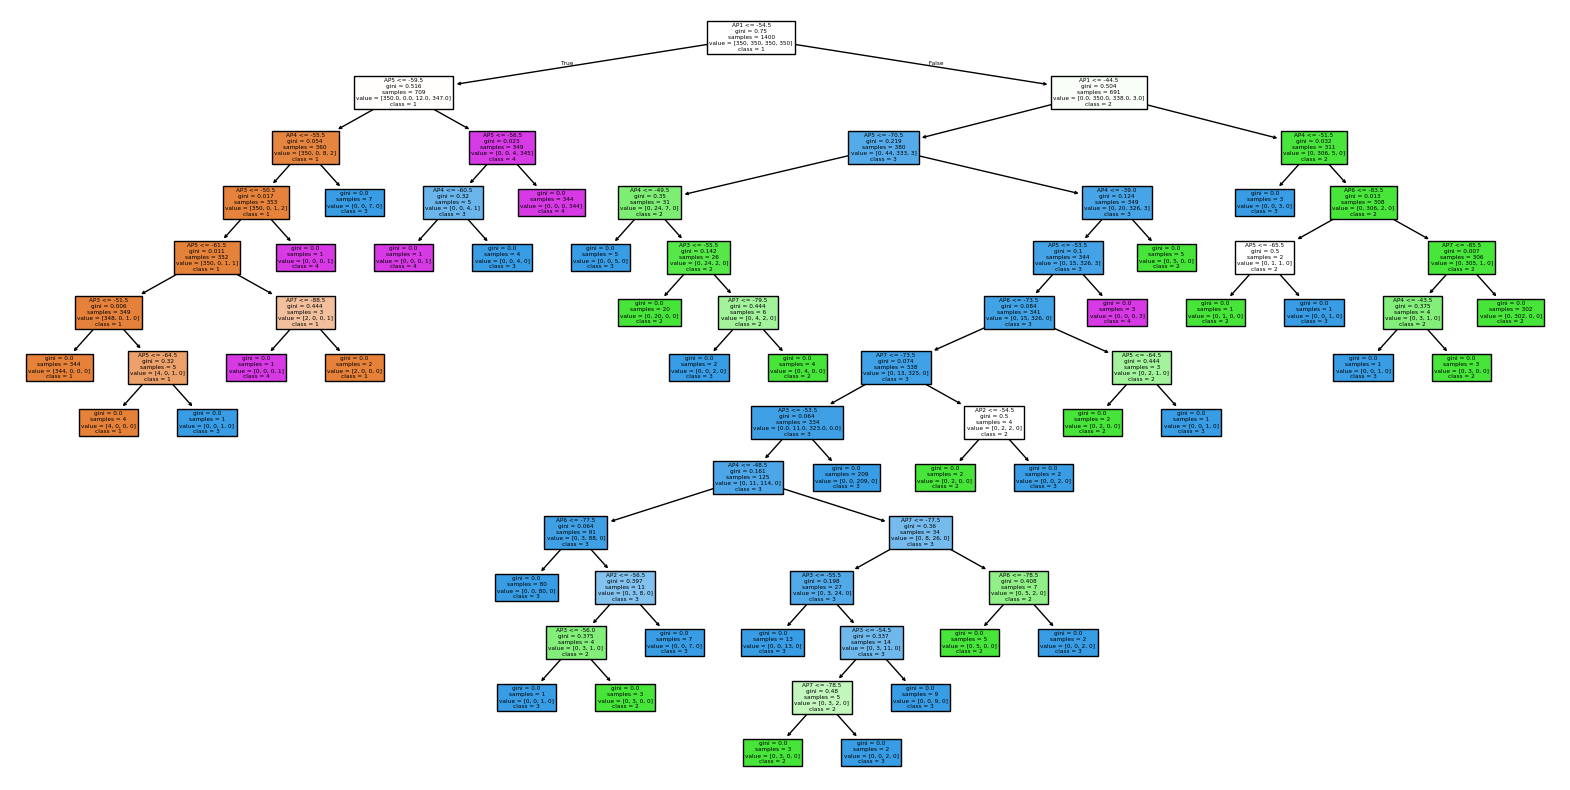

Atributo da raiz: AP1


In [9]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

print("Profundidade:", tree.get_depth())
print("Folhas:", tree.get_n_leaves())

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(np.unique(y))],
    filled=True
)

plt.show()

print("Atributo da raiz:",
      feature_names[tree.tree_.feature[0]])

O atributo utilizado na raiz é considerado o mais informativo para realizar a primeira separação dos dados, ele indica alta relevância para a classificação das salas.

### <font color='#2D9CDB'>Q8) Utilize a árvore de decisão treinada para realizar predições sobre o conjunto de teste. Em seguida, calcule a acurácia do modelo e apresente a matriz de confusão correspondente. Com base nos resultados obtidos, analise o desempenho do classificador e identifique quais salas foram classificadas com maior e menor precisão.</font>

Acurácia: 0.9733333333333334


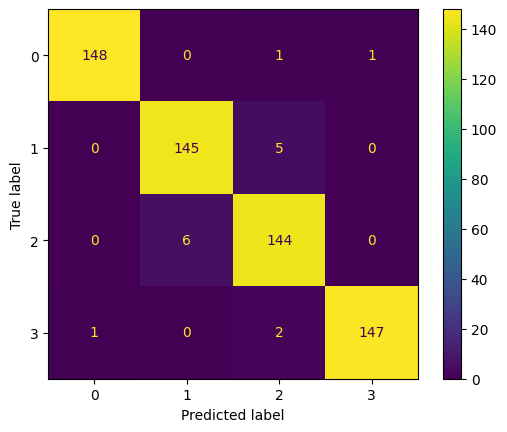

In [10]:
y_pred = tree.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("Acurácia:", acc)

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

A matriz de confusão permite identificar quais salas foram classificadas corretamente e quais apresentaram maior confusão entre si.

### <font color='#2D9CDB'>Q9) Treine novas árvores de decisão limitando a profundidade máxima (`max_depth`) aos valores de 1 a 15. Para cada modelo, calcule a acurácia nos conjuntos de treinamento e teste. Em seguida, organize os resultados em uma tabela e construa um gráfico comparando as acurácias obtidas. Com base nos resultados, analise como a profundidade influencia a complexidade e o desempenho do modelo. Por fim, identifique se há evidências de sobreajuste e indique qual profundidade parece oferecer o melhor equilíbrio entre capacidade de aprendizado e generalização.</font>

,Profundidade,Treino,Teste
0,1,0.500000,0.500000
1,2,0.952857,0.963333
2,3,0.974286,0.970000
3,4,0.982857,0.973333
4,5,0.985714,0.976667
5,6,0.989286,0.973333
6,7,0.990714,0.978333
7,8,0.992143,0.976667
8,9,0.992143,0.980000
9,10,0.994286,0.975000


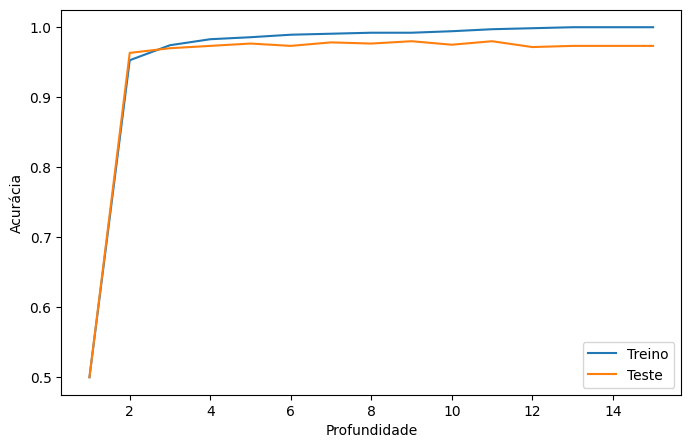

In [11]:
profundidades = range(1,16)

acc_train = []
acc_test = []

for d in profundidades:

    modelo = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    modelo.fit(X_train,y_train)

    acc_train.append(
        accuracy_score(y_train,
                       modelo.predict(X_train))
    )

    acc_test.append(
        accuracy_score(y_test,
                       modelo.predict(X_test))
    )

resultados = pd.DataFrame({
    "Profundidade": profundidades,
    "Treino": acc_train,
    "Teste": acc_test
})

display(resultados)

plt.figure(figsize=(8,5))
plt.plot(profundidades,acc_train,label="Treino")
plt.plot(profundidades,acc_test,label="Teste")
plt.legend()
plt.xlabel("Profundidade")
plt.ylabel("Acurácia")
plt.show()

Conforme a profundidade aumenta, a árvore torna-se mais complexa. Quando a acurácia de treino continua crescendo enquanto a de teste estabiliza ou diminui, há evidências de overfitting.

### <font color='#2D9CDB'>Q10) Utilizando a árvore de decisão treinada, obtenha a importância de cada atributo RSSI por meio da propriedade `feature_importances_`. Em seguida, construa um gráfico de barras ordenando os atributos do mais importante para o menos importante. Com base nos resultados, identifique quais pontos de acesso contribuíram mais para a classificação das salas e discuta por que alguns atributos podem ser mais relevantes do que outros para o problema de localização indoor.</font>

,0
AP1,0.562765
AP5,0.365961
AP4,0.038710
AP7,0.012060
AP3,0.008612
AP6,0.007260
AP2,0.004632


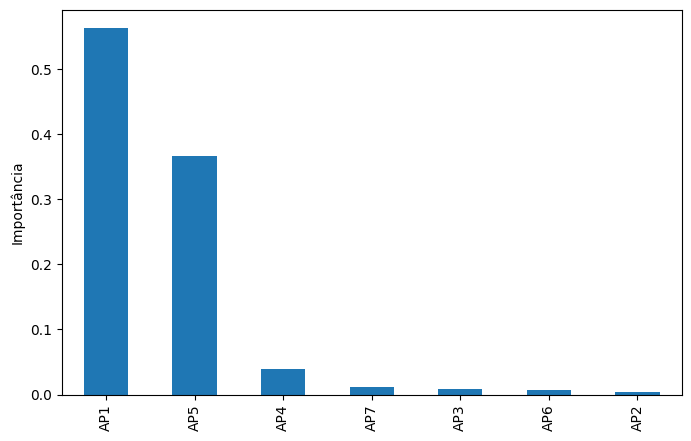

Dois atributos mais importantes:
['AP1', 'AP5']


In [12]:
importancias = pd.Series(
    tree.feature_importances_,
    index=feature_names
)

importancias = importancias.sort_values(
    ascending=False
)

display(importancias)

plt.figure(figsize=(8,5))
importancias.plot(kind="bar")
plt.ylabel("Importância")
plt.show()

top2 = importancias.index[:2].tolist()

print("Dois atributos mais importantes:")
print(top2)

Os APs mais importantes são aqueles que melhor diferenciam as salas, produzindo divisões mais informativas na árvore.

# <font color='green'><u><b>Parte 3 - K-Means</b></u></font>

### <font color='#2D9CDB'>Q11) Diferentemente das árvores de decisão, o algoritmo k-Means não utiliza rótulos durante o treinamento. Pesquise brevemente sobre esse método e descreva, em um único parágrafo, o que é clusterização, qual é o objetivo do algoritmo k-Means, o significado de um centroide e como o algoritmo utiliza a distância entre as amostras para formar agrupamentos.</font>

Clusterização é uma técnica de aprendizado não supervisionado cujo objetivo é agrupar amostras semelhantes sem utilizar rótulos previamente conhecidos.

O algoritmo k-Means busca particionar os dados em k grupos minimizando a distância entre as amostras e o centro do grupo ao qual pertencem. Cada grupo é representado por um centroide, que corresponde à média das observações atribuídas ao cluster.

Durante o treinamento, o algoritmo alterna entre atribuir cada amostra ao centroide mais próximo e recalcular os centroides, repetindo o processo até a convergência.

### <font color='#2D9CDB'>Q12) Considere os dois atributos mais importantes identificados na Q10. Construa um gráfico de dispersão utilizando essas variáveis, representando as amostras de cada sala com cores distintas e uma legenda apropriada. Com base na visualização obtida, analise a distribuição das amostras e discuta se existem agrupamentos naturais nos dados. Na sua opinião, seria possível identificar as diferentes salas sem utilizar os rótulos originais?</font>

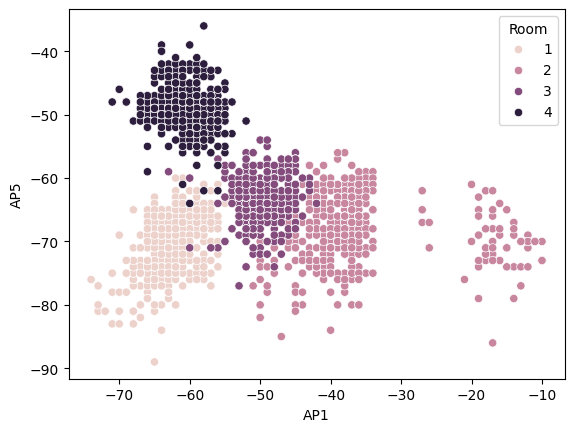

In [13]:
ap1 = top2[0]
ap2 = top2[1]

sns.scatterplot(
    data=df,
    x=ap1,
    y=ap2,
    hue="Room"
)

plt.show()

O gráfico permite visualizar se as salas formam agrupamentos naturais. Quanto maior a separação visual entre grupos, maior a chance de o k-Means identificar corretamente as salas sem utilizar os rótulos.

### <font color='#2D9CDB'>Q13) Antes de aplicar o algoritmo k-Means, é necessário definir o número de clusters (*k*). Utilize o Método do Cotovelo (Elbow Method) para avaliar valores de *k* entre 1 e 10. Para cada valor, calcule a inércia do modelo e construa um gráfico relacionando o número de clusters e a inércia obtida. Com base no gráfico, identifique o valor de *k* que parece mais adequado para este conjunto de dados e justifique sua escolha.</font>

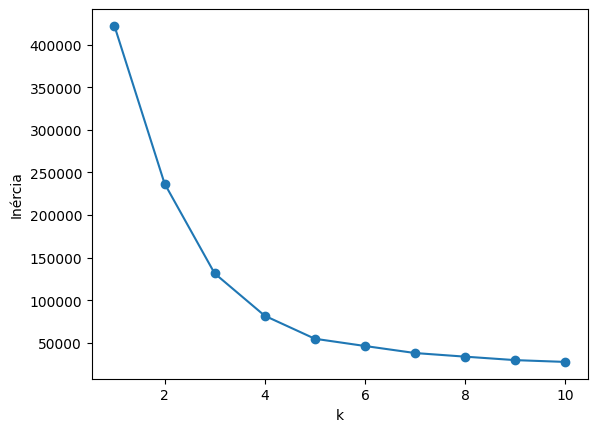

In [14]:
X_kmeans = df[[ap1,ap2]]

inercias = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_kmeans)

    inercias.append(km.inertia_)

plt.plot(range(1,11), inercias, marker="o")
plt.xlabel("k")
plt.ylabel("Inércia")
plt.show()

### <font color='#2D9CDB'>Q14) Utilizando o valor de *k* identificado na Q13, treine um modelo k-Means empregando apenas os atributos AP1 e AP5. Em seguida, apresente as coordenadas dos centroides encontrados e construa um gráfico de dispersão mostrando as amostras coloridas de acordo com o cluster atribuído pelo algoritmo. Destaque também os centroides no gráfico. Com base nos resultados, analise a qualidade dos agrupamentos obtidos.</font>

Centroides:
[[-60.20724346 -49.3722334 ]
 [-34.80100756 -67.82115869]
 [-62.37747036 -70.42490119]
 [-48.93166667 -63.63833333]]


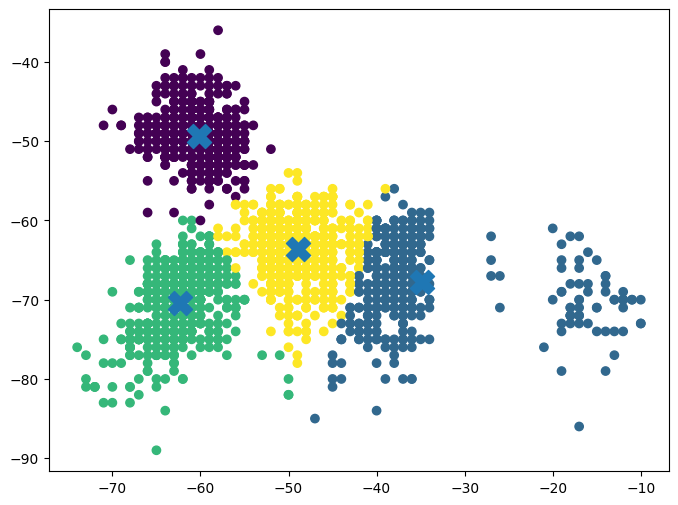

In [15]:
k = 4  # ajustar conforme Q13

km = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = km.fit_predict(X_kmeans)

centroides = km.cluster_centers_

print("Centroides:")
print(centroides)

plt.figure(figsize=(8,6))

plt.scatter(
    X_kmeans[ap1],
    X_kmeans[ap2],
    c=clusters
)

plt.scatter(
    centroides[:,0],
    centroides[:,1],
    marker="X",
    s=300
)

plt.show()

### <font color='#2D9CDB'>Q15) Compare os clusters encontrados pelo k-Means com as salas reais do dataset. Para isso, construa uma <a href="https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html">tabela de contingência</a> relacionando cada sala aos clusters atribuídos pelo algoritmo. Em seguida, identifique qual cluster representa predominantemente cada sala e calcule a porcentagem de amostras associadas a esse agrupamento. Com base nos resultados, discuta quais salas foram mais facilmente identificadas pelo algoritmo e quais apresentaram maior grau de confusão com outros grupos.</font>

In [16]:
tabela = pd.crosstab(
    df["Room"],
    clusters
)

display(tabela)

for sala in tabela.index:

    cluster = tabela.loc[sala].idxmax()

    porcentagem = (
        tabela.loc[sala].max()
        / tabela.loc[sala].sum()
    )*100

    print(
        f"Sala {sala}: "
        f"Cluster {cluster} "
        f"({porcentagem:.2f}%)"
    )

col_0,0,1,2,3
Room,,,,
1,0,0,493,7
2,0,396,4,100
3,3,0,7,490
4,494,0,2,4


Sala 1: Cluster 2 (98.60%)
Sala 2: Cluster 1 (79.20%)
Sala 3: Cluster 3 (98.00%)
Sala 4: Cluster 0 (98.80%)


# <font color='green'><u><b>Parte 4 - Detecção de Anomalias</b></u></font>

### <font color='#2D9CDB'>Q16) Uma aplicação comum de algoritmos de clusterização é a detecção de anomalias. Em geral, amostras localizadas muito longe do centroide de seu cluster podem representar comportamentos incomuns ou situações atípicas. Utilizando os dois atributos mais importantes identificados na Q10, calcule a distância euclidiana de cada amostra ao centroide do cluster ao qual ela foi atribuída pelo k-Means. Em seguida, apresente um histograma dessas distâncias e informe os valores mínimo, máximo, médio e o desvio padrão observados. Com base nos resultados, discuta o que essas distâncias revelam sobre a compactação dos clusters encontrados.</font>

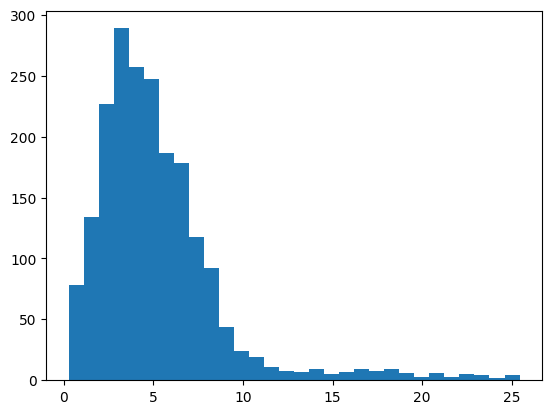

Mínimo: 0.2675485126101018
Máximo: 25.442997885480256
Média: 5.235469539845325
Desvio: 3.6667401656991565


In [17]:
distancias = np.linalg.norm(
    X_kmeans.values -
    centroides[clusters],
    axis=1
)

plt.hist(distancias,bins=30)
plt.show()

print("Mínimo:", distancias.min())
print("Máximo:", distancias.max())
print("Média:", distancias.mean())
print("Desvio:", distancias.std())

### <font color='#2D9CDB'>Q17) Considere que amostras muito distantes do centroide de seu cluster podem ser classificadas como potenciais anomalias. Utilize o percentil de 95% das distâncias calculadas na Q16 como limiar de detecção. Em seguida, identifique todas as amostras cuja distância ao centroide seja superior a esse valor, informe quantas anomalias foram encontradas e apresente as cinco amostras mais distantes de seus respectivos centroides. Com base nos resultados, discuta se o critério adotado parece adequado para identificar observações atípicas.</font>

In [18]:
limiar = np.percentile(distancias,95)

anomalias = df[distancias > limiar]

print("Limiar:", limiar)
print("Quantidade:", len(anomalias))

indices = np.argsort(distancias)[-5:]

display(df.iloc[indices])

Limiar: 11.61035075595776
Quantidade: 100


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
932,-11,-59,-60,-27,-70,-74,-71,2
870,-10,-58,-54,-18,-70,-72,-73,2
769,-10,-57,-57,-36,-73,-82,-72,2
873,-10,-58,-62,-20,-73,-76,-74,2
609,-17,-63,-65,-27,-86,-72,-74,2


### <font color='#2D9CDB'>Q18) Construa um gráfico de dispersão utilizando os dois atributos empregados pelo k-Means e destaque as anomalias identificadas na Q17. Represente também os centroides dos clusters. Com base na visualização obtida, avalie se as amostras classificadas como anômalas encontram-se em regiões afastadas dos centroides e discuta se os resultados são coerentes com o critério de detecção adotado.</font>

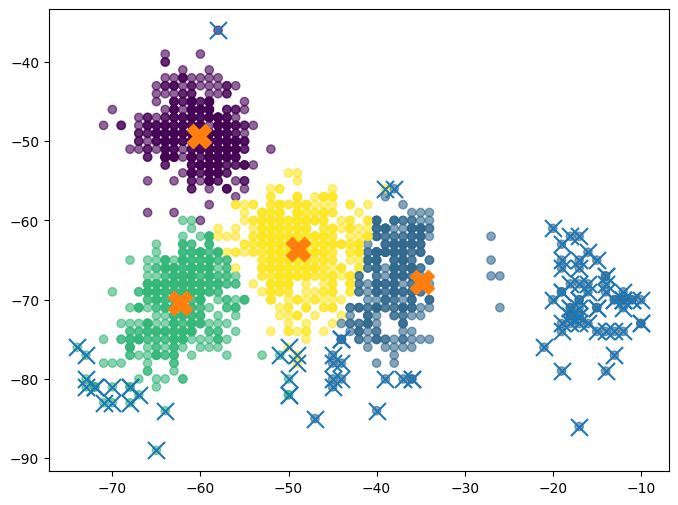

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_kmeans[ap1],
    X_kmeans[ap2],
    c=clusters,
    alpha=0.6
)

plt.scatter(
    X_kmeans.iloc[distancias > limiar][ap1],
    X_kmeans.iloc[distancias > limiar][ap2],
    marker='x',
    s=150
)

plt.scatter(
    centroides[:,0],
    centroides[:,1],
    marker='X',
    s=300
)

plt.show()

### <font color='#2D9CDB'>Q19) O limiar utilizado para detectar anomalias influencia diretamente a quantidade de observações classificadas como atípicas. Repita o procedimento da Q17 utilizando os percentis 90%, 95% e 99% das distâncias aos centroides. Para cada caso, registre o valor do limiar e o número de anomalias detectadas. Organize os resultados em uma tabela e discuta como a escolha do percentil afeta a sensibilidade do detector de anomalias.</font>

In [20]:
resultados = []

for p in [90,95,99]:

    limiar = np.percentile(distancias,p)

    qtd = np.sum(distancias > limiar)

    resultados.append([
        p,
        limiar,
        qtd
    ])

resultado_df = pd.DataFrame(
    resultados,
    columns=[
        "Percentil",
        "Limiar",
        "Anomalias"
    ]
)

display(resultado_df)

,Percentil,Limiar,Anomalias
0,90,8.577111,200
1,95,11.610351,100
2,99,20.817381,20


Percentis menores produzem mais anomalias e tornam o detector mais sensível. Percentis maiores reduzem a quantidade de observações classificadas como atípicas.

# <font color='green'><u><b>Parte 5 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q20) Ao longo desta atividade foram exploradas técnicas de aprendizado supervisionado (Árvores de Decisão) e não supervisionado (k-Means), além de uma abordagem simples para detecção de anomalias baseada na distância aos centroides. Compare essas três aplicações quanto aos seus objetivos, à utilização de rótulos durante o treinamento, aos resultados produzidos e às situações em que cada uma delas é mais adequada. Por fim, discuta como essas técnicas poderiam ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi.</font>

As Árvores de Decisão são técnicas de aprendizado supervisionado que utilizam rótulos conhecidos para construir regras capazes de classificar novas observações.

O k-Means é um método de aprendizado não supervisionado que busca agrupar amostras semelhantes sem utilizar informações sobre as classes reais, já a detecção de anomalias baseada em distância aos centroides procura identificar observações incomuns ou raras que se afastam significativamente do comportamento predominante dos grupos. Enquanto a árvore produz previsões explícitas de salas, o k-Means produz agrupamentos e a detecção de anomalias produz alertas sobre possíveis medições atípicas.

Em um sistema de localização indoor, o k-Means pode ser utilizado para descobrir padrões de posicionamento, a árvore de decisão para identificar automaticamente a sala do usuário e a detecção de anomalias para identificar leituras incorretas, falhas de sensores ou mudanças inesperadas no ambiente.